<a href="https://colab.research.google.com/github/ehdrb1023/GraduationProject/blob/main/Muon_SAM_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 구글 드라이브 연동 (실행 후 링크나 팝업창에서 권한 허용 눌러줘!)
from google.colab import drive
import os
import urllib.request

drive.mount('/content/drive')

# 2. 구글 드라이브 내에 졸업프로젝트 전용 데이터 폴더 생성
drive_data_path = '/content/drive/MyDrive/Colab_Data'
os.makedirs(drive_data_path, exist_ok=True)

# 3. CIFAR-10 압축본 다운로드 URL 지정 (fast.ai의 초고속 미러 서버)
cifar_url = 'https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz'
destination_path = os.path.join(drive_data_path, 'cifar10.tgz')

# 4. 다운로드 시작
if not os.path.exists(destination_path):
    print("🚀 구글 드라이브로 CIFAR-10 압축 파일 다운로드를 시작합니다...")
    print("대략 10초~20초 정도 소요됩니다. 잠시만 기다려주세요.")

    urllib.request.urlretrieve(cifar_url, destination_path)

    print("\n✅ 다운로드 완료!")
    print(f"파일 저장 위치: {destination_path}")
    print(f"현재 파일 크기: {os.path.getsize(destination_path) / (1024*1024):.2f} MB")
else:
    print("✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!")

Mounted at /content/drive
✨ 이미 구글 드라이브에 cifar10.tgz 파일이 안전하게 존재합니다!


In [2]:
import os
import time
import tarfile
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ 현재 사용 중인 장치: {device}\n")

# ==========================================
# 1. 초고속 데이터 압축 해제 (Drive -> Colab Local)
# ==========================================
drive_zip_path = '/content/drive/MyDrive/Colab_Data/cifar10.tgz'
local_extract_path = '/content/'
local_data_path = '/content/cifar10'  # fast.ai 압축을 풀면 나오는 기본 폴더명

if not os.path.exists(local_data_path):
    print("📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)")
    with tarfile.open(drive_zip_path, 'r:gz') as tar:
        tar.extractall(path=local_extract_path)
    print("✅ 로컬 압축 해제 완료!\n")
else:
    print("✨ 이미 코랩 로컬에 데이터가 압축 해제되어 있습니다.\n")

# ==========================================
# 2. 데이터셋 및 데이터로더 설정 (Data Augmentation)
# ==========================================
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

train_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'train'), transform=transform_train)
test_dataset = datasets.ImageFolder(root=os.path.join(local_data_path, 'test'), transform=transform_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

print(f"📊 학습 데이터: {len(train_dataset)}장 | 테스트 데이터: {len(test_dataset)}장 준비 완료\n")

🖥️ 현재 사용 중인 장치: cuda

📦 구글 드라이브에서 코랩 로컬로 데이터를 푸는 중... (약 10~15초 소요)


/tmp/ipykernel_865/2377517764.py:23: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=local_extract_path)


✅ 로컬 압축 해제 완료!

📊 학습 데이터: 50000장 | 테스트 데이터: 10000장 준비 완료



In [3]:
# ==========================================
# 3. 모델 정의 (ResNet-18 for CIFAR-10)
# ==========================================
def build_model():
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, 10)
    return m.to(device)

model = build_model()
print("✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!\n")

✅ ResNet-18 모델 로드 및 CIFAR-10 커스텀 완료!



In [4]:
# ==========================================
# 4. Muon 옵티마이저 (원본 그대로)
# ==========================================
@torch.no_grad()
def zeropower_via_newtonschulz5(G, steps=5, eps=1e-7):
    """Newton-Schulz 반복을 통한 Gradient 직교화 (Muon의 핵심 연산)"""
    assert len(G.shape) == 2
    a, b, c = (3.4445, -4.7750,  2.0315)
    X = G.bfloat16()
    X /= (X.norm() + eps)
    if G.size(0) > G.size(1):
        X = X.T
    for _ in range(steps):
        A = X @ X.T
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(0) > G.size(1):
        X = X.T
    return X.to(G.dtype)

class Muon(optim.Optimizer):
    def __init__(self, params, lr=0.02, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            for p in group['params']:
                g = p.grad
                if g is None:
                    continue

                state = self.state[p]
                if 'momentum_buffer' not in state:
                    state['momentum_buffer'] = torch.zeros_like(g)
                buf = state['momentum_buffer']

                original_shape = g.shape
                if g.ndim > 2:
                    g = g.view(g.size(0), -1)

                g_ortho = zeropower_via_newtonschulz5(g, steps=group['ns_steps'])
                g_ortho = g_ortho.view(original_shape)

                buf.mul_(group['momentum']).add_(g_ortho)
                if group['nesterov']:
                    g_update = g_ortho + group['momentum'] * buf
                else:
                    g_update = buf

                p.add_(g_update, alpha=-group['lr'])
        return loss

print("✅ Muon 옵티마이저 정의 완료!\n")

✅ Muon 옵티마이저 정의 완료!



In [5]:
# ==========================================
# 5. SAMAscent — 옵티마이저 독립적인 SAM perturbation
# ==========================================
class SAMAscent:
    """
    ★ v3의 핵심. SAM을 '옵티마이저'가 아니라 '그래디언트 변환기'로 분리한 것.

    기존 SAM 클래스는 base_optimizer를 내부에 소유해서, SAM을 쓰려면 옵티마이저를
    통째로 교체해야 했다 (→ Muon 소멸, 모멘텀 리셋).
    SAMAscent는 파라미터 perturbation만 담당하고 실제 step은 외부 옵티마이저
    (Muon/AdamW)에게 맡긴다. 따라서 옵티마이저 객체를 바꾸지 않고도 SAM을 켤 수 있다.

    ascent()  : w -> w + rho * g/||g||   (가장 나쁜 방향으로 임시 이동)
    restore() : w_adv -> w               (원위치 복원, step은 호출자가 수행)
    """
    def __init__(self, params, rho=0.05):
        self.params = [p for p in params if p.requires_grad]
        self.rho = rho
        self._e_w = {}

    def set_rho(self, rho):
        self.rho = rho

    @torch.no_grad()
    def _grad_norm(self):
        grads = [p.grad.norm(p=2) for p in self.params if p.grad is not None]
        if not grads:
            return torch.tensor(0.0)
        return torch.norm(torch.stack(grads), p=2)

    @torch.no_grad()
    def ascent(self):
        """rho<=0이면 아무것도 하지 않고 False 반환 (Phase 1에서 오버헤드 0)"""
        if self.rho <= 0:
            return False
        grad_norm = self._grad_norm()
        if grad_norm.item() < 1e-12:
            return False
        scale = self.rho / (grad_norm + 1e-12)
        self._e_w.clear()
        for p in self.params:
            if p.grad is None:
                continue
            e_w = p.grad * scale.to(p.device)
            p.add_(e_w)
            self._e_w[p] = e_w
        return True

    @torch.no_grad()
    def restore(self):
        for p, e_w in self._e_w.items():
            p.sub_(e_w)
        self._e_w.clear()

print("✅ SAMAscent 정의 완료! (옵티마이저 교체 없이 SAM 적용 가능)\n")

✅ SAMAscent 정의 완료! (옵티마이저 교체 없이 SAM 적용 가능)



In [6]:
# ==========================================
# 6. 램프형 전환 컨트롤러 + 진단 함수
# ==========================================
import collections

class RampSwitchController:
    """
    v1/v2의 2단계 트리거 아이디어는 유지하되, 전환을 '점프'가 아닌 '램프'로 바꿈.

    Phase 1 (rho=0)       : 순수 Muon+AdamW. Loss EMA가 임계값 이하 + 최근 N에폭 std가
                            조밀해지면 트리거 발동
    Phase 2 (rho 램프 중) : rho가 0 -> rho_max로 ramp_epochs에 걸쳐 선형 증가.
                            이 구간이 v1/v2에 없던 '완충 구간'
    Phase 3 (rho=rho_max) : 완전한 SAM-Muon 상태

    ⚠️ v1/v2와 달리 Phase가 바뀌어도 옵티마이저는 교체되지 않는다. rho 값만 변한다.
    """
    def __init__(self, rho_max=0.05, ramp_epochs=5,
                 coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
                 ema_alpha=0.3, mode='hybrid'):
        self.mode = mode
        self.rho_max = rho_max
        self.ramp_epochs = ramp_epochs
        self.coarse_loss_threshold = coarse_loss_threshold
        self.coarse_std_threshold = coarse_std_threshold
        self.ema_alpha = ema_alpha

        self.loss_ema = None
        self.loss_window = collections.deque(maxlen=coarse_window)
        self.trigger_epoch = None      # 램프가 시작된 에폭
        self.phase = 1

        if mode == 'sam_always':
            self.trigger_epoch = 0     # 처음부터 램프 시작
            self.phase = 2

    def current_rho(self, epoch):
        """이번 에폭에 적용할 rho 값을 반환"""
        if self.mode == 'muon_only':
            return 0.0
        if self.trigger_epoch is None:
            return 0.0
        # +1: 램프 첫 에폭부터 rho>0이 되도록 (안 그러면 첫 에폭이 rho=0으로 낭비됨)
        progress = (epoch - self.trigger_epoch + 1) / max(1, self.ramp_epochs)
        progress = min(1.0, max(0.0, progress))
        return self.rho_max * progress

    def update(self, epoch, epoch_train_loss):
        """에폭 종료 후 호출. 다음 에폭의 phase를 결정."""
        if self.mode == 'muon_only':
            self.phase = 1
            return self.phase

        self.loss_ema = epoch_train_loss if self.loss_ema is None \
            else self.ema_alpha * epoch_train_loss + (1 - self.ema_alpha) * self.loss_ema
        self.loss_window.append(epoch_train_loss)

        # Phase 1 -> 2 트리거 판정
        if self.trigger_epoch is None and len(self.loss_window) == self.loss_window.maxlen:
            loss_std = torch.tensor(list(self.loss_window)).std().item()
            if self.loss_ema <= self.coarse_loss_threshold and loss_std <= self.coarse_std_threshold:
                self.trigger_epoch = epoch + 1
                self.phase = 2
                print(f"\n🔍 [Phase 1→2] Loss EMA={self.loss_ema:.4f}, std={loss_std:.4f} "
                      f"→ epoch {self.trigger_epoch}부터 rho 램프 시작 "
                      f"(0 → {self.rho_max} over {self.ramp_epochs} epochs)\n")

        # Phase 2 -> 3 (램프 완료)
        if self.trigger_epoch is not None:
            if epoch + 1 >= self.trigger_epoch + self.ramp_epochs:
                if self.phase != 3:
                    print(f"\n🎯 [Phase 2→3] rho 램프 완료 → rho={self.rho_max} 고정, 완전 SAM-Muon\n")
                self.phase = 3
            else:
                self.phase = 2
        return self.phase


def measure_sharpness(model, criterion, probe_batches, device, rho=0.05):
    """
    고정된 probe 배치로 sharpness L(w+eps)-L(w)를 측정.
    ★ 학습에 쓰는 rho와 무관하게 항상 rho=0.05로 고정 측정하므로,
      Phase가 달라져도 / MODE가 달라져도 값을 그대로 비교할 수 있다.
    """
    was_training = model.training
    model.eval()
    diffs = []
    for inputs, targets in probe_batches:
        inputs, targets = inputs.to(device), targets.to(device)

        with torch.no_grad():
            loss_w = criterion(model(inputs), targets).item()

        model.zero_grad(set_to_none=True)
        criterion(model(inputs), targets).backward()

        grads = [p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]
        grad_norm = torch.norm(torch.stack(grads), p=2)
        scale = rho / (grad_norm + 1e-12)

        e_ws = []
        with torch.no_grad():
            for p in model.parameters():
                if p.grad is None:
                    continue
                e_w = p.grad * scale
                p.add_(e_w)
                e_ws.append((p, e_w))
            loss_w_eps = criterion(model(inputs), targets).item()
            for p, e_w in e_ws:
                p.sub_(e_w)

        model.zero_grad(set_to_none=True)
        diffs.append(loss_w_eps - loss_w)

    if was_training:
        model.train()
    return sum(diffs) / len(diffs)


def evaluate(model_to_eval, loader):
    model_to_eval.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model_to_eval(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

print("✅ 컨트롤러 + 진단 함수 정의 완료!\n")

✅ 컨트롤러 + 진단 함수 정의 완료!



In [7]:
# ==========================================
# 7. 학습 루프 (Overlay 하이브리드)
# ==========================================
# ┌──────────────────────────────────────────────────────────┐
# │ MODE를 바꿔가며 3번 돌려야 실험이 완성됩니다.              │
# │   'muon_only'  : rho=0 고정 (cosine 스케줄 적용 베이스라인) │
# │   'sam_always' : 0에폭부터 rho 램프 (always-on 대조군)     │
# │   'hybrid'     : 동적 트리거로 램프 시작 (본 실험)         │
# └──────────────────────────────────────────────────────────┘
MODE = 'hybrid'

EPOCHS = 50
MUON_LR = 0.02
ADAMW_LR = 3e-4
RHO_MAX = 0.05
RAMP_EPOCHS = 5           # rho를 0→RHO_MAX로 올리는 데 걸리는 에폭 수 (전환 충격 완충)
SHARPNESS_INTERVAL = 2    # 몇 에폭마다 sharpness를 측정할지
GRAD_CLIP = 1.0           # None이면 클리핑 없음

# ---- 매 실행마다 새 모델로 시작 (공정 비교 필수) ----
torch.manual_seed(42)
model = build_model()

muon_params, adamw_params = [], []
for name, param in model.named_parameters():
    (muon_params if param.ndim >= 2 else adamw_params).append(param)

optimizer_muon = Muon(muon_params, lr=MUON_LR, momentum=0.95)
optimizer_adamw = optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01)

# ★ 개선 4: Cosine 스케줄러 (v1/v2에는 없었음 — Muon이 후반에 수렴 못 하던 원인)
sched_muon = optim.lr_scheduler.CosineAnnealingLR(optimizer_muon, T_max=EPOCHS)
sched_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=EPOCHS)

sam = SAMAscent(model.parameters(), rho=0.0)

controller = RampSwitchController(
    rho_max=RHO_MAX, ramp_epochs=RAMP_EPOCHS,
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    mode=MODE,
)

criterion = nn.CrossEntropyLoss()

# sharpness 측정을 위한 고정 probe 배치 (매번 같은 데이터 → 값 비교 가능)
probe_batches = []
_probe_iter = iter(train_loader)
for _ in range(3):
    probe_batches.append(next(_probe_iter))

history = {'epoch': [], 'phase': [], 'rho': [], 'train_loss': [], 'train_acc': [],
           'test_acc': [], 'lr_muon': [], 'lr_adamw': [], 'grad_norm': [],
           'ascent_gap': [], 'time': []}
sharpness_history = {'epoch': [], 'sharpness': []}

print(f"🚀 CIFAR-10 학습 시작 — MODE={MODE}, {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    rho_now = controller.current_rho(epoch)
    sam.set_rho(rho_now)
    phase = controller.phase

    model.train()
    running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
    correct, total = 0, 0
    n_batches = 0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_muon.zero_grad(set_to_none=True)
        optimizer_adamw.zero_grad(set_to_none=True)

        # ---- 1차 forward/backward (원래 위치 w) ----
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        # train accuracy 집계
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        with torch.no_grad():
            gnorm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]), p=2).item()
        running_gnorm += gnorm

        gap = 0.0
        # ---- SAM ascent (rho>0일 때만) ----
        if sam.ascent():
            optimizer_muon.zero_grad(set_to_none=True)
            optimizer_adamw.zero_grad(set_to_none=True)

            # ---- 2차 forward/backward (perturbed 위치 w_adv) ----
            loss_adv = criterion(model(inputs), targets)
            loss_adv.backward()
            gap = loss_adv.item() - loss.item()

            sam.restore()   # w_adv -> w 복원. grad는 w_adv 것이 남아있음

        # ★ 개선 1의 핵심: 옵티마이저를 교체하지 않고 그대로 step
        #   → Muon 모멘텀 버퍼, AdamW 상태가 전부 연속으로 유지됨
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer_muon.step()
        optimizer_adamw.step()

        running_loss += loss.item()
        running_gap += gap
        n_batches += 1

    sched_muon.step()
    sched_adamw.step()

    epoch_time = time.time() - start_time
    train_loss = running_loss / n_batches
    train_acc = 100. * correct / total
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase)
    history['rho'].append(rho_now)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr_muon'].append(optimizer_muon.param_groups[0]['lr'])
    history['lr_adamw'].append(optimizer_adamw.param_groups[0]['lr'])
    history['grad_norm'].append(running_gnorm / n_batches)
    history['ascent_gap'].append(running_gap / n_batches)
    history['time'].append(epoch_time)

    sharp_str = ""
    if (epoch + 1) % SHARPNESS_INTERVAL == 0 or epoch == EPOCHS - 1:
        sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sv)
        sharp_str = f" | Sharp: {sv:.4f}"

    phase_tag = {1: "P1-Muon", 2: "P2-Ramp", 3: "P3-SAMMuon"}[phase]
    print(f"[{phase_tag}] Ep [{epoch+1}/{EPOCHS}] | {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
          f"rho: {rho_now:.4f}{sharp_str}")

    controller.update(epoch, train_loss)

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
final_sharpness = sharpness_history['sharpness'][-1]

print(f"\n🎉 학습 종료! (MODE={MODE})")
print(f"   - 최종 Test Acc : {history['test_acc'][-1]:.2f}%")
print(f"   - 최고 Test Acc : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   - 최종 Sharpness: {final_sharpness:.4f}")
print(f"   - 총 학습 시간  : {sum(history['time'])/60:.1f}분")
if controller.trigger_epoch is not None:
    print(f"   - rho 램프 시작 : epoch {controller.trigger_epoch}")

🚀 CIFAR-10 학습 시작 — MODE=hybrid, 50 epochs

[P1-Muon] Ep [1/50] | 50.2s | Loss: 1.4651 | Train: 50.81% | Test: 64.43% | rho: 0.0000
[P1-Muon] Ep [2/50] | 50.5s | Loss: 1.0324 | Train: 66.66% | Test: 69.17% | rho: 0.0000 | Sharp: 0.0924
[P1-Muon] Ep [3/50] | 50.4s | Loss: 0.8559 | Train: 72.18% | Test: 74.79% | rho: 0.0000
[P1-Muon] Ep [4/50] | 49.8s | Loss: 0.7739 | Train: 74.76% | Test: 76.70% | rho: 0.0000 | Sharp: 0.0924
[P1-Muon] Ep [5/50] | 49.7s | Loss: 0.7076 | Train: 76.92% | Test: 78.19% | rho: 0.0000
[P1-Muon] Ep [6/50] | 50.7s | Loss: 0.6627 | Train: 78.52% | Test: 78.70% | rho: 0.0000 | Sharp: 0.1155
[P1-Muon] Ep [7/50] | 49.6s | Loss: 0.6477 | Train: 79.30% | Test: 79.79% | rho: 0.0000
[P1-Muon] Ep [8/50] | 49.8s | Loss: 0.6159 | Train: 80.79% | Test: 79.77% | rho: 0.0000 | Sharp: 0.1509
[P1-Muon] Ep [9/50] | 50.6s | Loss: 0.5758 | Train: 81.74% | Test: 81.16% | rho: 0.0000
[P1-Muon] Ep [10/50] | 50.0s | Loss: 0.5535 | Train: 82.34% | Test: 81.11% | rho: 0.0000 | Sharp: 0.1

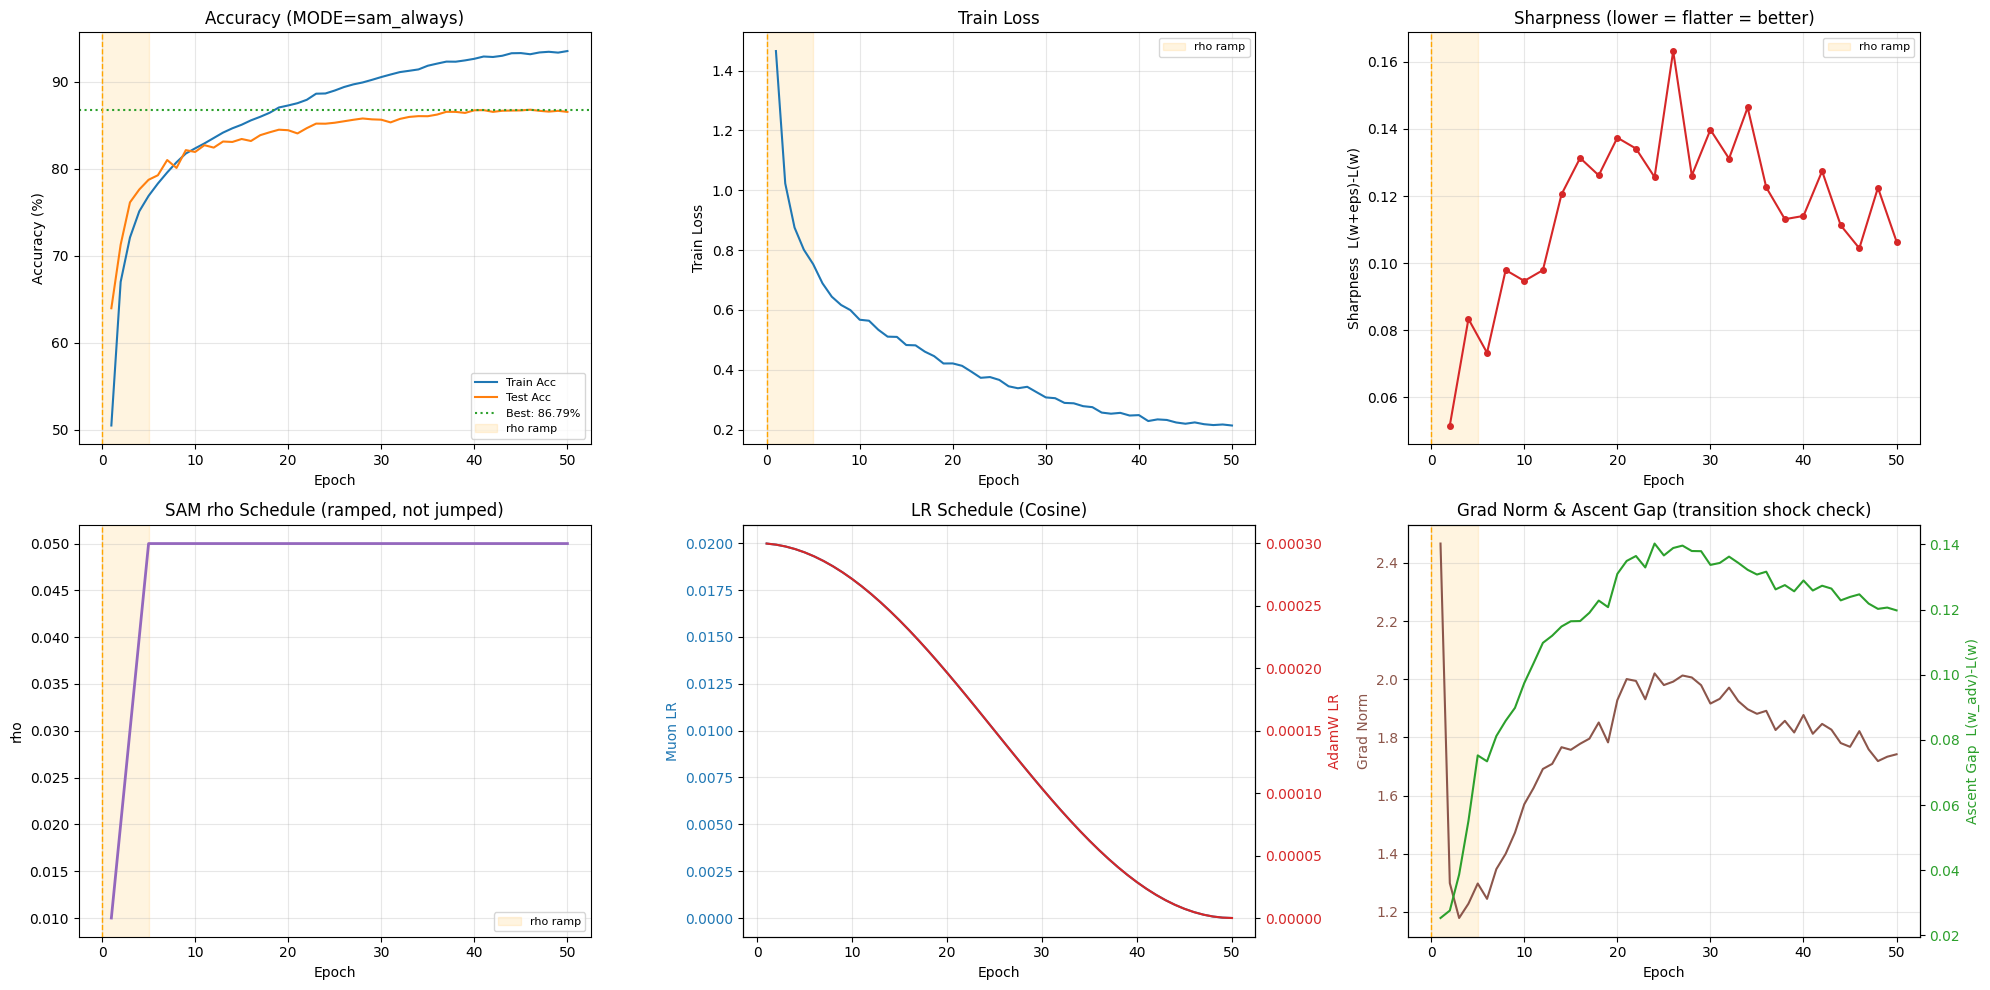


📊 요약
   MODE            : sam_always
   최종 Test Acc   : 86.54%
   최고 Test Acc   : 86.79% (epoch 46)
   최종 Sharpness  : 0.1064
   총 학습 시간    : 58.2분

   [참고] v1/v2 실험 기록
   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%


In [13]:
# ==========================================
# 8. 결과 시각화
# ==========================================
# (matplotlib 기본 폰트가 한글을 지원하지 않아 그래프 안 텍스트는 영어로 표기)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
ramp_start = controller.trigger_epoch
ramp_end = (controller.trigger_epoch + controller.ramp_epochs) if ramp_start is not None else None

def shade_phases(ax):
    """rho 램프 구간을 음영으로 표시"""
    if ramp_start is not None:
        ax.axvspan(ramp_start, min(ramp_end, EPOCHS), color='orange', alpha=0.12,
                   label='rho ramp')
        ax.axvline(ramp_start, color='orange', linestyle='--', linewidth=1)

# 1. Accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], color='tab:blue', label='Train Acc', linewidth=1.5)
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', label='Test Acc', linewidth=1.5)
ax.axhline(best_acc, color='tab:green', linestyle=':', label=f'Best: {best_acc:.2f}%')
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Accuracy (MODE={MODE})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Train Loss
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Sharpness — 낮을수록 flat minima (SAM의 목표)
ax = axes[0, 2]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
        color='tab:red', marker='o', markersize=4, linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness  L(w+eps)-L(w)')
ax.set_title('Sharpness (lower = flatter = better)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. rho 스케줄 — v3의 핵심인 '점프가 아닌 램프'
ax = axes[1, 0]
ax.plot(history['epoch'], history['rho'], color='tab:purple', linewidth=2)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('rho')
ax.set_title('SAM rho Schedule (ramped, not jumped)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. LR 스케줄
ax = axes[1, 1]
ax.plot(history['epoch'], history['lr_muon'], color='tab:blue', label='Muon LR', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Muon LR', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['lr_adamw'], color='tab:red', label='AdamW LR', linewidth=1.5)
ax2.set_ylabel('AdamW LR', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax.set_title('LR Schedule (Cosine)')
ax.grid(alpha=0.3)

# 6. Gradient Norm + Ascent Gap — 전환 충격이 있었는지 진단
ax = axes[1, 2]
ax.plot(history['epoch'], history['grad_norm'], color='tab:brown', label='Grad Norm', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Grad Norm', color='tab:brown')
ax.tick_params(axis='y', labelcolor='tab:brown')
shade_phases(ax)
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['ascent_gap'], color='tab:green',
         label='Ascent Gap', linewidth=1.5)
ax2.set_ylabel('Ascent Gap  L(w_adv)-L(w)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.set_title('Grad Norm & Ascent Gap (transition shock check)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/hybrid_v3_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   MODE            : {MODE}")
print(f"   최종 Test Acc   : {history['test_acc'][-1]:.2f}%")
print(f"   최고 Test Acc   : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   최종 Sharpness  : {final_sharpness:.4f}")
print(f"   총 학습 시간    : {sum(history['time'])/60:.1f}분")
print("\n   [참고] v1/v2 실험 기록")
print("   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%")

In [14]:
# ==========================================
# 9. 결과 저장 (MyDrive) — MODE별로 따로 저장되어 나중에 비교 가능
# ==========================================
import json
from datetime import datetime

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f'v3_{MODE}_{timestamp}'

run_record = {
    'run_name': run_name,
    'mode': MODE,
    'design': 'overlay (SAM ascent + Muon/AdamW step, no optimizer swap)',
    'config': {
        'epochs': EPOCHS, 'muon_lr': MUON_LR, 'adamw_lr': ADAMW_LR,
        'rho_max': RHO_MAX, 'ramp_epochs': RAMP_EPOCHS, 'grad_clip': GRAD_CLIP,
        'lr_schedule': 'CosineAnnealingLR',
    },
    'results': {
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_train_acc': history['train_acc'][-1],
        'final_train_loss': history['train_loss'][-1],
        'final_sharpness': final_sharpness,
        'total_time_min': sum(history['time']) / 60,
        'ramp_start_epoch': controller.trigger_epoch,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}

with open(os.path.join(save_dir, f'{run_name}.json'), 'w', encoding='utf-8') as f:
    json.dump(run_record, f, ensure_ascii=False, indent=2)

torch.save(model.state_dict(), os.path.join(save_dir, f'{run_name}_model.pt'))

print(f"✅ 저장 완료: {save_dir}/{run_name}.json")
print(f"   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.")

✅ 저장 완료: /content/drive/MyDrive/Colab_Data/hybrid_experiments/v3_sam_always_20260819_110645.json
   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.


In [11]:
# ==========================================
# 7. 학습 루프 (Overlay 하이브리드)
# ==========================================
# ┌──────────────────────────────────────────────────────────┐
# │ MODE를 바꿔가며 3번 돌려야 실험이 완성됩니다.              │
# │   'muon_only'  : rho=0 고정 (cosine 스케줄 적용 베이스라인) │
# │   'sam_always' : 0에폭부터 rho 램프 (always-on 대조군)     │
# │   'hybrid'     : 동적 트리거로 램프 시작 (본 실험)         │
# └──────────────────────────────────────────────────────────┘
MODE = 'muon_only'

EPOCHS = 50
MUON_LR = 0.02
ADAMW_LR = 3e-4
RHO_MAX = 0.05
RAMP_EPOCHS = 5           # rho를 0→RHO_MAX로 올리는 데 걸리는 에폭 수 (전환 충격 완충)
SHARPNESS_INTERVAL = 2    # 몇 에폭마다 sharpness를 측정할지
GRAD_CLIP = 1.0           # None이면 클리핑 없음

# ---- 매 실행마다 새 모델로 시작 (공정 비교 필수) ----
torch.manual_seed(42)
model = build_model()

muon_params, adamw_params = [], []
for name, param in model.named_parameters():
    (muon_params if param.ndim >= 2 else adamw_params).append(param)

optimizer_muon = Muon(muon_params, lr=MUON_LR, momentum=0.95)
optimizer_adamw = optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01)

# ★ 개선 4: Cosine 스케줄러 (v1/v2에는 없었음 — Muon이 후반에 수렴 못 하던 원인)
sched_muon = optim.lr_scheduler.CosineAnnealingLR(optimizer_muon, T_max=EPOCHS)
sched_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=EPOCHS)

sam = SAMAscent(model.parameters(), rho=0.0)

controller = RampSwitchController(
    rho_max=RHO_MAX, ramp_epochs=RAMP_EPOCHS,
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    mode=MODE,
)

criterion = nn.CrossEntropyLoss()

# sharpness 측정을 위한 고정 probe 배치 (매번 같은 데이터 → 값 비교 가능)
probe_batches = []
_probe_iter = iter(train_loader)
for _ in range(3):
    probe_batches.append(next(_probe_iter))

history = {'epoch': [], 'phase': [], 'rho': [], 'train_loss': [], 'train_acc': [],
           'test_acc': [], 'lr_muon': [], 'lr_adamw': [], 'grad_norm': [],
           'ascent_gap': [], 'time': []}
sharpness_history = {'epoch': [], 'sharpness': []}

print(f"🚀 CIFAR-10 학습 시작 — MODE={MODE}, {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    rho_now = controller.current_rho(epoch)
    sam.set_rho(rho_now)
    phase = controller.phase

    model.train()
    running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
    correct, total = 0, 0
    n_batches = 0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_muon.zero_grad(set_to_none=True)
        optimizer_adamw.zero_grad(set_to_none=True)

        # ---- 1차 forward/backward (원래 위치 w) ----
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        # train accuracy 집계
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        with torch.no_grad():
            gnorm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]), p=2).item()
        running_gnorm += gnorm

        gap = 0.0
        # ---- SAM ascent (rho>0일 때만) ----
        if sam.ascent():
            optimizer_muon.zero_grad(set_to_none=True)
            optimizer_adamw.zero_grad(set_to_none=True)

            # ---- 2차 forward/backward (perturbed 위치 w_adv) ----
            loss_adv = criterion(model(inputs), targets)
            loss_adv.backward()
            gap = loss_adv.item() - loss.item()

            sam.restore()   # w_adv -> w 복원. grad는 w_adv 것이 남아있음

        # ★ 개선 1의 핵심: 옵티마이저를 교체하지 않고 그대로 step
        #   → Muon 모멘텀 버퍼, AdamW 상태가 전부 연속으로 유지됨
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer_muon.step()
        optimizer_adamw.step()

        running_loss += loss.item()
        running_gap += gap
        n_batches += 1

    sched_muon.step()
    sched_adamw.step()

    epoch_time = time.time() - start_time
    train_loss = running_loss / n_batches
    train_acc = 100. * correct / total
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase)
    history['rho'].append(rho_now)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr_muon'].append(optimizer_muon.param_groups[0]['lr'])
    history['lr_adamw'].append(optimizer_adamw.param_groups[0]['lr'])
    history['grad_norm'].append(running_gnorm / n_batches)
    history['ascent_gap'].append(running_gap / n_batches)
    history['time'].append(epoch_time)

    sharp_str = ""
    if (epoch + 1) % SHARPNESS_INTERVAL == 0 or epoch == EPOCHS - 1:
        sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sv)
        sharp_str = f" | Sharp: {sv:.4f}"

    phase_tag = {1: "P1-Muon", 2: "P2-Ramp", 3: "P3-SAMMuon"}[phase]
    print(f"[{phase_tag}] Ep [{epoch+1}/{EPOCHS}] | {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
          f"rho: {rho_now:.4f}{sharp_str}")

    controller.update(epoch, train_loss)

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
final_sharpness = sharpness_history['sharpness'][-1]

print(f"\n🎉 학습 종료! (MODE={MODE})")
print(f"   - 최종 Test Acc : {history['test_acc'][-1]:.2f}%")
print(f"   - 최고 Test Acc : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   - 최종 Sharpness: {final_sharpness:.4f}")
print(f"   - 총 학습 시간  : {sum(history['time'])/60:.1f}분")
if controller.trigger_epoch is not None:
    print(f"   - rho 램프 시작 : epoch {controller.trigger_epoch}")

🚀 CIFAR-10 학습 시작 — MODE=muon_only, 50 epochs

[P1-Muon] Ep [1/50] | 51.2s | Loss: 1.4736 | Train: 50.30% | Test: 64.01% | rho: 0.0000
[P1-Muon] Ep [2/50] | 51.7s | Loss: 1.0545 | Train: 66.53% | Test: 71.10% | rho: 0.0000 | Sharp: 0.0866
[P1-Muon] Ep [3/50] | 52.2s | Loss: 0.8910 | Train: 72.19% | Test: 75.90% | rho: 0.0000
[P1-Muon] Ep [4/50] | 51.3s | Loss: 0.8005 | Train: 74.65% | Test: 75.62% | rho: 0.0000 | Sharp: 0.0864
[P1-Muon] Ep [5/50] | 51.2s | Loss: 0.7253 | Train: 77.04% | Test: 78.23% | rho: 0.0000
[P1-Muon] Ep [6/50] | 51.9s | Loss: 0.6710 | Train: 78.38% | Test: 79.08% | rho: 0.0000 | Sharp: 0.0861
[P1-Muon] Ep [7/50] | 50.9s | Loss: 0.6485 | Train: 79.73% | Test: 79.50% | rho: 0.0000
[P1-Muon] Ep [8/50] | 50.7s | Loss: 0.6149 | Train: 80.50% | Test: 79.77% | rho: 0.0000 | Sharp: 0.1200
[P1-Muon] Ep [9/50] | 51.9s | Loss: 0.5898 | Train: 81.72% | Test: 81.56% | rho: 0.0000
[P1-Muon] Ep [10/50] | 51.1s | Loss: 0.5784 | Train: 82.12% | Test: 82.16% | rho: 0.0000 | Sharp: 

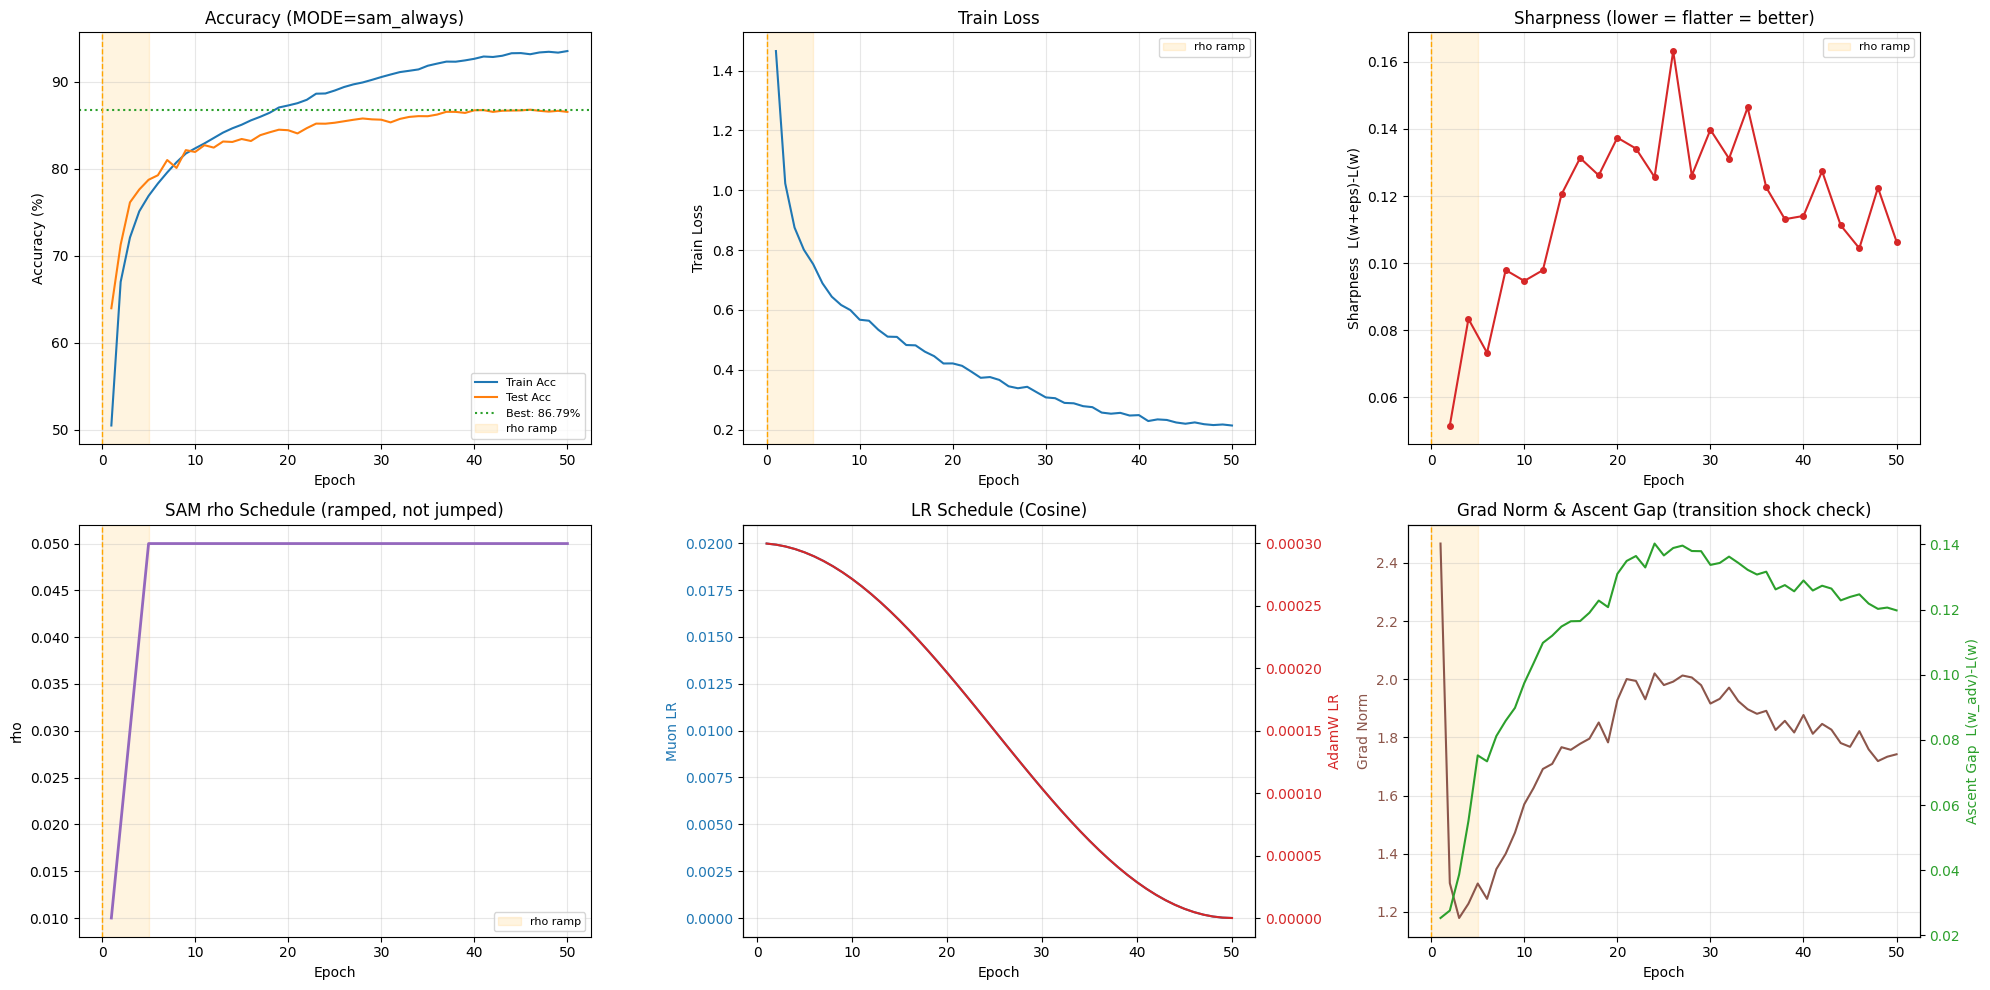


📊 요약
   MODE            : sam_always
   최종 Test Acc   : 86.54%
   최고 Test Acc   : 86.79% (epoch 46)
   최종 Sharpness  : 0.1064
   총 학습 시간    : 58.2분

   [참고] v1/v2 실험 기록
   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%


In [15]:
# ==========================================
# 8. 결과 시각화
# ==========================================
# (matplotlib 기본 폰트가 한글을 지원하지 않아 그래프 안 텍스트는 영어로 표기)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
ramp_start = controller.trigger_epoch
ramp_end = (controller.trigger_epoch + controller.ramp_epochs) if ramp_start is not None else None

def shade_phases(ax):
    """rho 램프 구간을 음영으로 표시"""
    if ramp_start is not None:
        ax.axvspan(ramp_start, min(ramp_end, EPOCHS), color='orange', alpha=0.12,
                   label='rho ramp')
        ax.axvline(ramp_start, color='orange', linestyle='--', linewidth=1)

# 1. Accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], color='tab:blue', label='Train Acc', linewidth=1.5)
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', label='Test Acc', linewidth=1.5)
ax.axhline(best_acc, color='tab:green', linestyle=':', label=f'Best: {best_acc:.2f}%')
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Accuracy (MODE={MODE})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Train Loss
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Sharpness — 낮을수록 flat minima (SAM의 목표)
ax = axes[0, 2]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
        color='tab:red', marker='o', markersize=4, linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness  L(w+eps)-L(w)')
ax.set_title('Sharpness (lower = flatter = better)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. rho 스케줄 — v3의 핵심인 '점프가 아닌 램프'
ax = axes[1, 0]
ax.plot(history['epoch'], history['rho'], color='tab:purple', linewidth=2)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('rho')
ax.set_title('SAM rho Schedule (ramped, not jumped)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. LR 스케줄
ax = axes[1, 1]
ax.plot(history['epoch'], history['lr_muon'], color='tab:blue', label='Muon LR', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Muon LR', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['lr_adamw'], color='tab:red', label='AdamW LR', linewidth=1.5)
ax2.set_ylabel('AdamW LR', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax.set_title('LR Schedule (Cosine)')
ax.grid(alpha=0.3)

# 6. Gradient Norm + Ascent Gap — 전환 충격이 있었는지 진단
ax = axes[1, 2]
ax.plot(history['epoch'], history['grad_norm'], color='tab:brown', label='Grad Norm', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Grad Norm', color='tab:brown')
ax.tick_params(axis='y', labelcolor='tab:brown')
shade_phases(ax)
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['ascent_gap'], color='tab:green',
         label='Ascent Gap', linewidth=1.5)
ax2.set_ylabel('Ascent Gap  L(w_adv)-L(w)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.set_title('Grad Norm & Ascent Gap (transition shock check)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/hybrid_v3_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   MODE            : {MODE}")
print(f"   최종 Test Acc   : {history['test_acc'][-1]:.2f}%")
print(f"   최고 Test Acc   : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   최종 Sharpness  : {final_sharpness:.4f}")
print(f"   총 학습 시간    : {sum(history['time'])/60:.1f}분")
print("\n   [참고] v1/v2 실험 기록")
print("   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%")

In [16]:
# ==========================================
# 9. 결과 저장 (MyDrive) — MODE별로 따로 저장되어 나중에 비교 가능
# ==========================================
import json
from datetime import datetime

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f'v3_{MODE}_{timestamp}'

run_record = {
    'run_name': run_name,
    'mode': MODE,
    'design': 'overlay (SAM ascent + Muon/AdamW step, no optimizer swap)',
    'config': {
        'epochs': EPOCHS, 'muon_lr': MUON_LR, 'adamw_lr': ADAMW_LR,
        'rho_max': RHO_MAX, 'ramp_epochs': RAMP_EPOCHS, 'grad_clip': GRAD_CLIP,
        'lr_schedule': 'CosineAnnealingLR',
    },
    'results': {
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_train_acc': history['train_acc'][-1],
        'final_train_loss': history['train_loss'][-1],
        'final_sharpness': final_sharpness,
        'total_time_min': sum(history['time']) / 60,
        'ramp_start_epoch': controller.trigger_epoch,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}

with open(os.path.join(save_dir, f'{run_name}.json'), 'w', encoding='utf-8') as f:
    json.dump(run_record, f, ensure_ascii=False, indent=2)

torch.save(model.state_dict(), os.path.join(save_dir, f'{run_name}_model.pt'))

print(f"✅ 저장 완료: {save_dir}/{run_name}.json")
print(f"   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.")

✅ 저장 완료: /content/drive/MyDrive/Colab_Data/hybrid_experiments/v3_sam_always_20260819_110647.json
   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.


In [12]:
# ==========================================
# 7. 학습 루프 (Overlay 하이브리드)
# ==========================================
# ┌──────────────────────────────────────────────────────────┐
# │ MODE를 바꿔가며 3번 돌려야 실험이 완성됩니다.              │
# │   'muon_only'  : rho=0 고정 (cosine 스케줄 적용 베이스라인) │
# │   'sam_always' : 0에폭부터 rho 램프 (always-on 대조군)     │
# │   'hybrid'     : 동적 트리거로 램프 시작 (본 실험)         │
# └──────────────────────────────────────────────────────────┘
MODE = 'sam_always'

EPOCHS = 50
MUON_LR = 0.02
ADAMW_LR = 3e-4
RHO_MAX = 0.05
RAMP_EPOCHS = 5           # rho를 0→RHO_MAX로 올리는 데 걸리는 에폭 수 (전환 충격 완충)
SHARPNESS_INTERVAL = 2    # 몇 에폭마다 sharpness를 측정할지
GRAD_CLIP = 1.0           # None이면 클리핑 없음

# ---- 매 실행마다 새 모델로 시작 (공정 비교 필수) ----
torch.manual_seed(42)
model = build_model()

muon_params, adamw_params = [], []
for name, param in model.named_parameters():
    (muon_params if param.ndim >= 2 else adamw_params).append(param)

optimizer_muon = Muon(muon_params, lr=MUON_LR, momentum=0.95)
optimizer_adamw = optim.AdamW(adamw_params, lr=ADAMW_LR, weight_decay=0.01)

# ★ 개선 4: Cosine 스케줄러 (v1/v2에는 없었음 — Muon이 후반에 수렴 못 하던 원인)
sched_muon = optim.lr_scheduler.CosineAnnealingLR(optimizer_muon, T_max=EPOCHS)
sched_adamw = optim.lr_scheduler.CosineAnnealingLR(optimizer_adamw, T_max=EPOCHS)

sam = SAMAscent(model.parameters(), rho=0.0)

controller = RampSwitchController(
    rho_max=RHO_MAX, ramp_epochs=RAMP_EPOCHS,
    coarse_loss_threshold=0.5, coarse_window=3, coarse_std_threshold=0.03,
    mode=MODE,
)

criterion = nn.CrossEntropyLoss()

# sharpness 측정을 위한 고정 probe 배치 (매번 같은 데이터 → 값 비교 가능)
probe_batches = []
_probe_iter = iter(train_loader)
for _ in range(3):
    probe_batches.append(next(_probe_iter))

history = {'epoch': [], 'phase': [], 'rho': [], 'train_loss': [], 'train_acc': [],
           'test_acc': [], 'lr_muon': [], 'lr_adamw': [], 'grad_norm': [],
           'ascent_gap': [], 'time': []}
sharpness_history = {'epoch': [], 'sharpness': []}

print(f"🚀 CIFAR-10 학습 시작 — MODE={MODE}, {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    rho_now = controller.current_rho(epoch)
    sam.set_rho(rho_now)
    phase = controller.phase

    model.train()
    running_loss, running_gap, running_gnorm = 0.0, 0.0, 0.0
    correct, total = 0, 0
    n_batches = 0
    start_time = time.time()

    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer_muon.zero_grad(set_to_none=True)
        optimizer_adamw.zero_grad(set_to_none=True)

        # ---- 1차 forward/backward (원래 위치 w) ----
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()

        # train accuracy 집계
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()

        with torch.no_grad():
            gnorm = torch.norm(torch.stack([
                p.grad.norm(p=2) for p in model.parameters() if p.grad is not None]), p=2).item()
        running_gnorm += gnorm

        gap = 0.0
        # ---- SAM ascent (rho>0일 때만) ----
        if sam.ascent():
            optimizer_muon.zero_grad(set_to_none=True)
            optimizer_adamw.zero_grad(set_to_none=True)

            # ---- 2차 forward/backward (perturbed 위치 w_adv) ----
            loss_adv = criterion(model(inputs), targets)
            loss_adv.backward()
            gap = loss_adv.item() - loss.item()

            sam.restore()   # w_adv -> w 복원. grad는 w_adv 것이 남아있음

        # ★ 개선 1의 핵심: 옵티마이저를 교체하지 않고 그대로 step
        #   → Muon 모멘텀 버퍼, AdamW 상태가 전부 연속으로 유지됨
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP)
        optimizer_muon.step()
        optimizer_adamw.step()

        running_loss += loss.item()
        running_gap += gap
        n_batches += 1

    sched_muon.step()
    sched_adamw.step()

    epoch_time = time.time() - start_time
    train_loss = running_loss / n_batches
    train_acc = 100. * correct / total
    test_acc = evaluate(model, test_loader)

    history['epoch'].append(epoch + 1)
    history['phase'].append(phase)
    history['rho'].append(rho_now)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    history['lr_muon'].append(optimizer_muon.param_groups[0]['lr'])
    history['lr_adamw'].append(optimizer_adamw.param_groups[0]['lr'])
    history['grad_norm'].append(running_gnorm / n_batches)
    history['ascent_gap'].append(running_gap / n_batches)
    history['time'].append(epoch_time)

    sharp_str = ""
    if (epoch + 1) % SHARPNESS_INTERVAL == 0 or epoch == EPOCHS - 1:
        sv = measure_sharpness(model, criterion, probe_batches, device, rho=0.05)
        sharpness_history['epoch'].append(epoch + 1)
        sharpness_history['sharpness'].append(sv)
        sharp_str = f" | Sharp: {sv:.4f}"

    phase_tag = {1: "P1-Muon", 2: "P2-Ramp", 3: "P3-SAMMuon"}[phase]
    print(f"[{phase_tag}] Ep [{epoch+1}/{EPOCHS}] | {epoch_time:.1f}s | "
          f"Loss: {train_loss:.4f} | Train: {train_acc:.2f}% | Test: {test_acc:.2f}% | "
          f"rho: {rho_now:.4f}{sharp_str}")

    controller.update(epoch, train_loss)

best_acc = max(history['test_acc'])
best_epoch = history['epoch'][history['test_acc'].index(best_acc)]
final_sharpness = sharpness_history['sharpness'][-1]

print(f"\n🎉 학습 종료! (MODE={MODE})")
print(f"   - 최종 Test Acc : {history['test_acc'][-1]:.2f}%")
print(f"   - 최고 Test Acc : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   - 최종 Sharpness: {final_sharpness:.4f}")
print(f"   - 총 학습 시간  : {sum(history['time'])/60:.1f}분")
if controller.trigger_epoch is not None:
    print(f"   - rho 램프 시작 : epoch {controller.trigger_epoch}")

🚀 CIFAR-10 학습 시작 — MODE=sam_always, 50 epochs

[P2-Ramp] Ep [1/50] | 70.3s | Loss: 1.4652 | Train: 50.46% | Test: 63.95% | rho: 0.0100
[P2-Ramp] Ep [2/50] | 70.2s | Loss: 1.0227 | Train: 66.99% | Test: 71.27% | rho: 0.0200 | Sharp: 0.0516
[P2-Ramp] Ep [3/50] | 69.8s | Loss: 0.8752 | Train: 72.09% | Test: 76.13% | rho: 0.0300
[P2-Ramp] Ep [4/50] | 70.1s | Loss: 0.8010 | Train: 75.10% | Test: 77.61% | rho: 0.0400 | Sharp: 0.0834
[P2-Ramp] Ep [5/50] | 70.1s | Loss: 0.7529 | Train: 76.88% | Test: 78.73% | rho: 0.0500

🎯 [Phase 2→3] rho 램프 완료 → rho=0.05 고정, 완전 SAM-Muon

[P3-SAMMuon] Ep [6/50] | 70.2s | Loss: 0.6889 | Train: 78.30% | Test: 79.25% | rho: 0.0500 | Sharp: 0.0733
[P3-SAMMuon] Ep [7/50] | 69.8s | Loss: 0.6440 | Train: 79.57% | Test: 81.00% | rho: 0.0500
[P3-SAMMuon] Ep [8/50] | 69.9s | Loss: 0.6163 | Train: 80.74% | Test: 80.09% | rho: 0.0500 | Sharp: 0.0979
[P3-SAMMuon] Ep [9/50] | 69.8s | Loss: 0.5992 | Train: 81.75% | Test: 82.14% | rho: 0.0500
[P3-SAMMuon] Ep [10/50] | 70.0s 

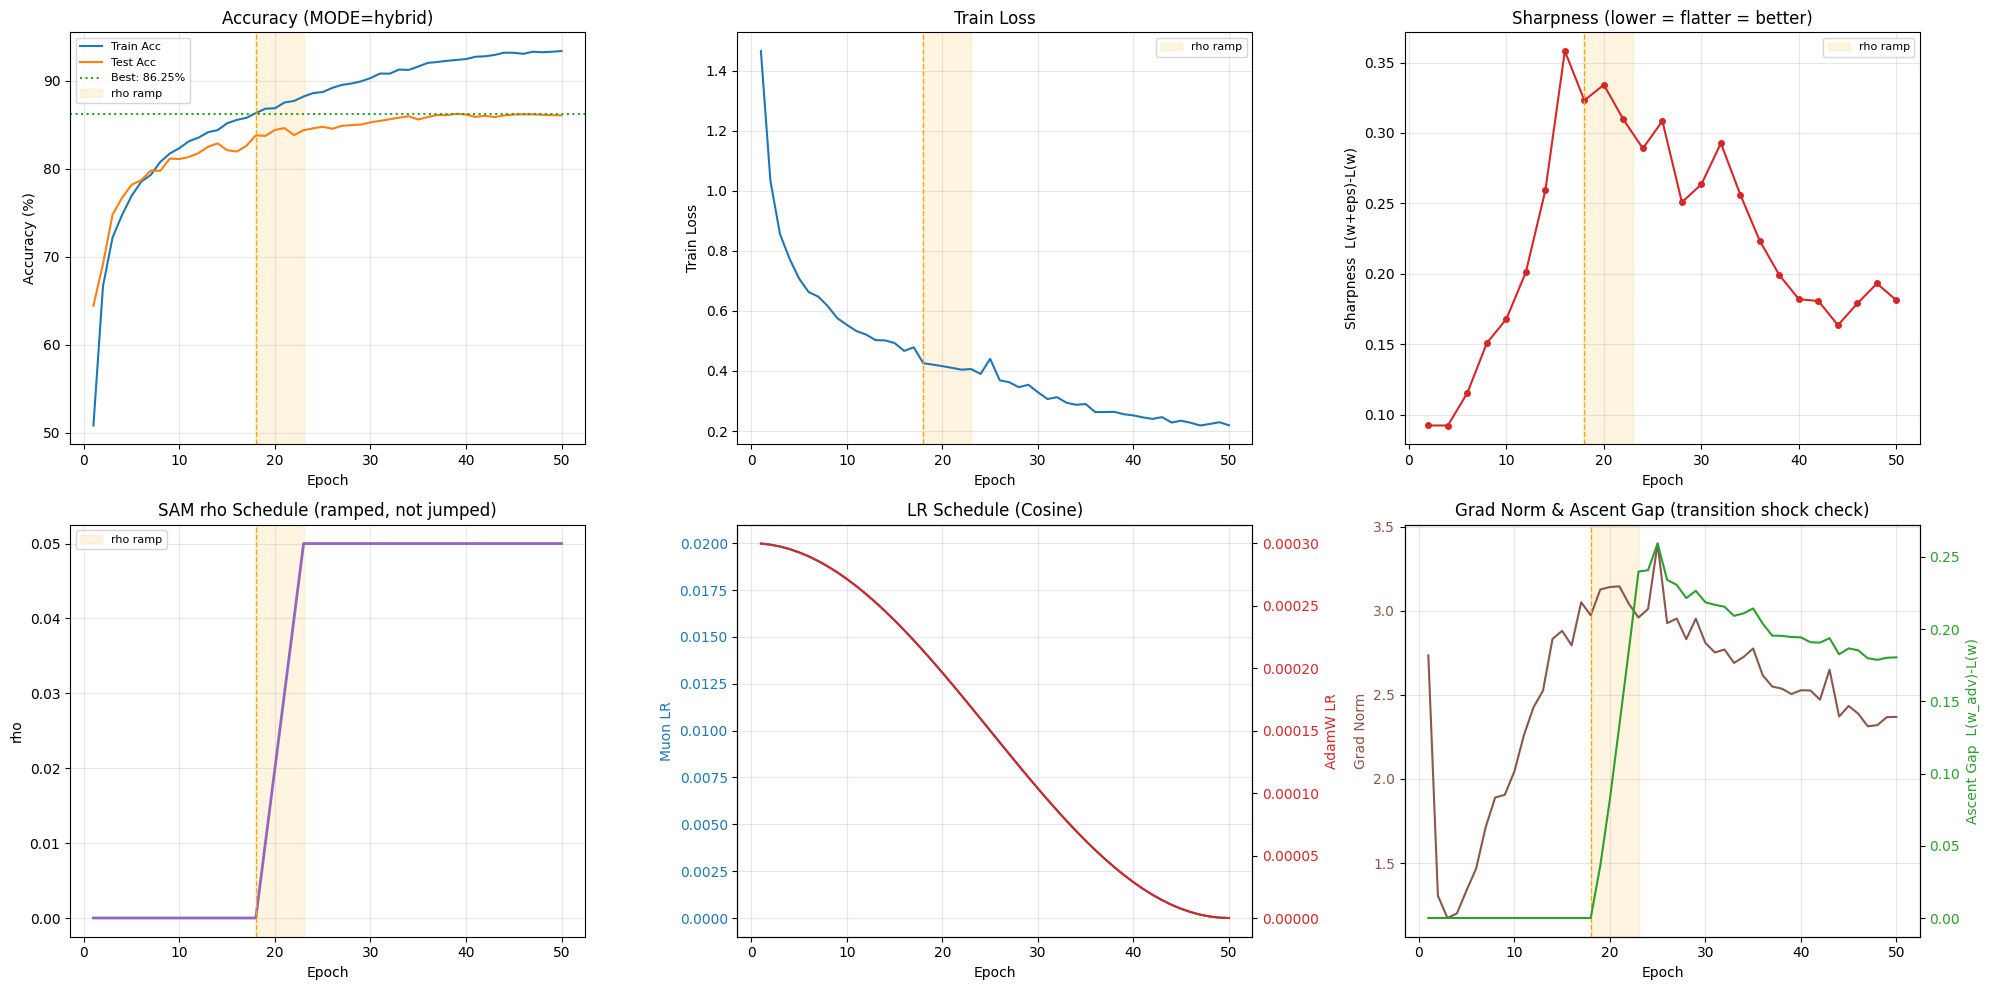


📊 요약
   MODE            : hybrid
   최종 Test Acc   : 86.07%
   최고 Test Acc   : 86.25% (epoch 39)
   최종 Sharpness  : 0.1812
   총 학습 시간    : 52.4분

   [참고] v1/v2 실험 기록
   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%


In [8]:
# ==========================================
# 8. 결과 시각화
# ==========================================
# (matplotlib 기본 폰트가 한글을 지원하지 않아 그래프 안 텍스트는 영어로 표기)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
ramp_start = controller.trigger_epoch
ramp_end = (controller.trigger_epoch + controller.ramp_epochs) if ramp_start is not None else None

def shade_phases(ax):
    """rho 램프 구간을 음영으로 표시"""
    if ramp_start is not None:
        ax.axvspan(ramp_start, min(ramp_end, EPOCHS), color='orange', alpha=0.12,
                   label='rho ramp')
        ax.axvline(ramp_start, color='orange', linestyle='--', linewidth=1)

# 1. Accuracy
ax = axes[0, 0]
ax.plot(history['epoch'], history['train_acc'], color='tab:blue', label='Train Acc', linewidth=1.5)
ax.plot(history['epoch'], history['test_acc'], color='tab:orange', label='Test Acc', linewidth=1.5)
ax.axhline(best_acc, color='tab:green', linestyle=':', label=f'Best: {best_acc:.2f}%')
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)'); ax.set_title(f'Accuracy (MODE={MODE})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 2. Train Loss
ax = axes[0, 1]
ax.plot(history['epoch'], history['train_loss'], color='tab:blue', linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Train Loss'); ax.set_title('Train Loss')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 3. Sharpness — 낮을수록 flat minima (SAM의 목표)
ax = axes[0, 2]
ax.plot(sharpness_history['epoch'], sharpness_history['sharpness'],
        color='tab:red', marker='o', markersize=4, linewidth=1.5)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness  L(w+eps)-L(w)')
ax.set_title('Sharpness (lower = flatter = better)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 4. rho 스케줄 — v3의 핵심인 '점프가 아닌 램프'
ax = axes[1, 0]
ax.plot(history['epoch'], history['rho'], color='tab:purple', linewidth=2)
shade_phases(ax)
ax.set_xlabel('Epoch'); ax.set_ylabel('rho')
ax.set_title('SAM rho Schedule (ramped, not jumped)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# 5. LR 스케줄
ax = axes[1, 1]
ax.plot(history['epoch'], history['lr_muon'], color='tab:blue', label='Muon LR', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Muon LR', color='tab:blue')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['lr_adamw'], color='tab:red', label='AdamW LR', linewidth=1.5)
ax2.set_ylabel('AdamW LR', color='tab:red')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax.set_title('LR Schedule (Cosine)')
ax.grid(alpha=0.3)

# 6. Gradient Norm + Ascent Gap — 전환 충격이 있었는지 진단
ax = axes[1, 2]
ax.plot(history['epoch'], history['grad_norm'], color='tab:brown', label='Grad Norm', linewidth=1.5)
ax.set_xlabel('Epoch'); ax.set_ylabel('Grad Norm', color='tab:brown')
ax.tick_params(axis='y', labelcolor='tab:brown')
shade_phases(ax)
ax2 = ax.twinx()
ax2.plot(history['epoch'], history['ascent_gap'], color='tab:green',
         label='Ascent Gap', linewidth=1.5)
ax2.set_ylabel('Ascent Gap  L(w_adv)-L(w)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')
ax.set_title('Grad Norm & Ascent Gap (transition shock check)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'/content/hybrid_v3_{MODE}.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 요약")
print(f"   MODE            : {MODE}")
print(f"   최종 Test Acc   : {history['test_acc'][-1]:.2f}%")
print(f"   최고 Test Acc   : {best_acc:.2f}% (epoch {best_epoch})")
print(f"   최종 Sharpness  : {final_sharpness:.4f}")
print(f"   총 학습 시간    : {sum(history['time'])/60:.1f}분")
print("\n   [참고] v1/v2 실험 기록")
print("   Muon 단독 85.35% | SAM 단독 94.69% | AdamW 92.93% | 하이브리드 v1 84.43%")

In [9]:
# ==========================================
# 9. 결과 저장 (MyDrive) — MODE별로 따로 저장되어 나중에 비교 가능
# ==========================================
import json
from datetime import datetime

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
os.makedirs(save_dir, exist_ok=True)

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
run_name = f'v3_{MODE}_{timestamp}'

run_record = {
    'run_name': run_name,
    'mode': MODE,
    'design': 'overlay (SAM ascent + Muon/AdamW step, no optimizer swap)',
    'config': {
        'epochs': EPOCHS, 'muon_lr': MUON_LR, 'adamw_lr': ADAMW_LR,
        'rho_max': RHO_MAX, 'ramp_epochs': RAMP_EPOCHS, 'grad_clip': GRAD_CLIP,
        'lr_schedule': 'CosineAnnealingLR',
    },
    'results': {
        'final_test_acc': history['test_acc'][-1],
        'best_test_acc': best_acc,
        'best_epoch': best_epoch,
        'final_train_acc': history['train_acc'][-1],
        'final_train_loss': history['train_loss'][-1],
        'final_sharpness': final_sharpness,
        'total_time_min': sum(history['time']) / 60,
        'ramp_start_epoch': controller.trigger_epoch,
    },
    'history': history,
    'sharpness_history': sharpness_history,
}

with open(os.path.join(save_dir, f'{run_name}.json'), 'w', encoding='utf-8') as f:
    json.dump(run_record, f, ensure_ascii=False, indent=2)

torch.save(model.state_dict(), os.path.join(save_dir, f'{run_name}_model.pt'))

print(f"✅ 저장 완료: {save_dir}/{run_name}.json")
print(f"   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.")

✅ 저장 완료: /content/drive/MyDrive/Colab_Data/hybrid_experiments/v3_hybrid_20260819_091731.json
   3개 MODE를 모두 돌린 뒤, 아래 셀에서 한 번에 비교할 수 있습니다.


📂 불러온 실험: ['hybrid']



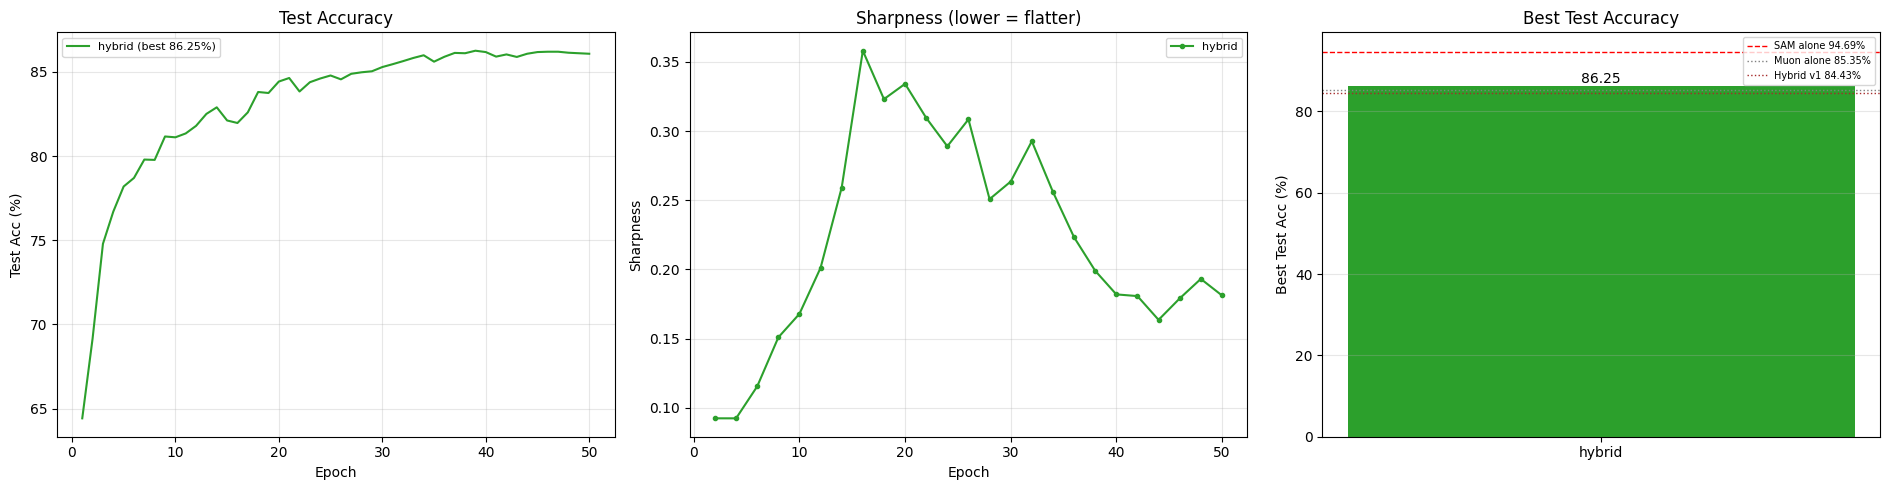


📊 통합 비교표
MODE             Best Acc   Final Acc   Sharpness   Time(min)
------------------------------------------------------------
hybrid             86.25%      86.07%      0.1812        52.4
------------------------------------------------------------
[v1 hybrid]        84.43%                                    
[SAM alone]        94.69%                                    


In [10]:
# ==========================================
# 10. 3개 MODE 결과 통합 비교 (3번 다 돌린 뒤 실행)
# ==========================================
import glob
import matplotlib.pyplot as plt

save_dir = '/content/drive/MyDrive/Colab_Data/hybrid_experiments'
files = sorted(glob.glob(os.path.join(save_dir, 'v3_*.json')))

runs = {}
for fp in files:
    with open(fp, encoding='utf-8') as f:
        rec = json.load(f)
    runs[rec['mode']] = rec   # 같은 MODE가 여러 개면 가장 최근 것이 남음

if not runs:
    print("⚠️ 저장된 결과가 없습니다. MODE를 바꿔가며 셀 7~9를 먼저 실행하세요.")
else:
    print(f"📂 불러온 실험: {list(runs.keys())}\n")

    colors = {'muon_only': 'tab:blue', 'sam_always': 'tab:orange', 'hybrid': 'tab:green'}

    fig, axes = plt.subplots(1, 3, figsize=(19, 5))

    # Test Acc 비교
    ax = axes[0]
    for mode, rec in runs.items():
        ax.plot(rec['history']['epoch'], rec['history']['test_acc'],
                label=f"{mode} (best {rec['results']['best_test_acc']:.2f}%)",
                color=colors.get(mode), linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test Acc (%)'); ax.set_title('Test Accuracy')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Sharpness 비교
    ax = axes[1]
    for mode, rec in runs.items():
        ax.plot(rec['sharpness_history']['epoch'], rec['sharpness_history']['sharpness'],
                label=mode, color=colors.get(mode), marker='o', markersize=3, linewidth=1.5)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Sharpness')
    ax.set_title('Sharpness (lower = flatter)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # 최종 성능 막대
    ax = axes[2]
    modes = list(runs.keys())
    accs = [runs[m]['results']['best_test_acc'] for m in modes]
    bars = ax.bar(modes, accs, color=[colors.get(m, 'gray') for m in modes])
    for bar, v in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.2f}', ha='center', va='bottom')
    # v1/v2 베이스라인 참고선
    ax.axhline(94.69, color='red', linestyle='--', linewidth=1, label='SAM alone 94.69%')
    ax.axhline(85.35, color='gray', linestyle=':', linewidth=1, label='Muon alone 85.35%')
    ax.axhline(84.43, color='brown', linestyle=':', linewidth=1, label='Hybrid v1 84.43%')
    ax.set_ylabel('Best Test Acc (%)'); ax.set_title('Best Test Accuracy')
    ax.legend(fontsize=7); ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.savefig('/content/hybrid_v3_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n📊 통합 비교표")
    print(f"{'MODE':<14} {'Best Acc':>10} {'Final Acc':>11} {'Sharpness':>11} {'Time(min)':>11}")
    print("-" * 60)
    for mode, rec in runs.items():
        r = rec['results']
        print(f"{mode:<14} {r['best_test_acc']:>9.2f}% {r['final_test_acc']:>10.2f}% "
              f"{r['final_sharpness']:>11.4f} {r['total_time_min']:>11.1f}")
    print("-" * 60)
    print(f"{'[v1 hybrid]':<14} {84.43:>9.2f}% {'':>11} {'':>11} {'':>11}")
    print(f"{'[SAM alone]':<14} {94.69:>9.2f}% {'':>11} {'':>11} {'':>11}")